# DataTour — Baseline améliorée

**Pipeline :**
1. Feature Engineering (anomalies, ratios, target-encoding OOF)
2. LightGBM + StratifiedKFold (5 folds)
3. Évaluation PR-AUC out-of-fold
4. Génération de `submission_baseline.csv`

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("dataset")
SEED     = 42
N_FOLDS  = 5

train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Train : {train.shape}  |  Test : {test.shape}")
print(f"Taux de fraude : {train['fraud_flag'].mean():.4%}")
display(train.head(3))


Train : (1290081, 11)  |  Test : (430100, 10)
Taux de fraude : 10.0414%


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,dtf_0000001_ffa5beb5,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0
1,dtf_0000002_61992e82,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0
2,dtf_0000003_9a123b6d,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0


## Feature Engineering

Basé sur les insights EDA :
- Toute la fraude est dans `op_03`
- Anomalies comptables (solde inchangé, variation ≠ montant)
- Ratios montant / solde
- Target encoding des comptes (OOF pour éviter le leakage)
- Features temporelles

In [ ]:
def build_features(df):
    """Features de base (sans target encoding)."""
    df = df.copy()

    # Opération encodée
    df["is_op03"] = (df["operation"] == "op_03").astype(int)

    #Montant
    df["amount_log"] = np.log1p(df["amount"])

    # Variations de sold
    df["orig_chg"] = df["origin_balance_after"]  - df["origin_balance_before"]
    df["dest_chg"] = df["destination_balance_after"] - df["destination_balance_before"]

    # Flags anomalies comptables
    eps = 0.5
    df["orig_no_move"] = ((df["orig_chg"].abs() < 0.01) & (df["amount"] > 0)).astype(int)
    df["dest_no_move"] = ((df["dest_chg"].abs() < 0.01) & (df["amount"] > 0)).astype(int)
    df["weird_orig"]   = ((df["orig_chg"] + df["amount"]).abs() > eps).astype(int)
    df["weird_dest"]   = ((df["dest_chg"] - df["amount"]).abs() > eps).astype(int)

    # Ratios montant / solde 
    eps2 = 1e-6
    df["amt_to_orig_before"] = df["amount"] / (df["origin_balance_before"].abs() + eps2)
    df["amt_to_dest_before"] = df["amount"] / (df["destination_balance_before"].abs() + eps2)
    df["orig_chg_ratio"]     = df["orig_chg"]  / (df["amount"] + eps2)
    df["dest_chg_ratio"]     = df["dest_chg"]  / (df["amount"] + eps2)

    # Soldes négatifs
    df["orig_bal_neg"] = (df["origin_balance_before"] < 0).astype(int)

    return df

train = build_features(train)
test  = build_features(test)
print("Features de base construites.")
print(train.shape)


Features de base construites.
(1290081, 24)


In [ ]:
# Fréquence-encoding des comptes
for col in ["origin_account", "destination_account"]:
    freq = train[col].value_counts(normalize=True).to_dict()
    train[f"{col}_freq"] = train[col].map(freq).fillna(0)
    test[f"{col}_freq"]  = test[col].map(freq).fillna(0)

# Agrégations comportementales (sur le train complet)
orig_stats = train.groupby("origin_account").agg(
    orig_n_tx        = ("fraud_flag", "count"),
    orig_n_dest      = ("destination_account", "nunique"),
    orig_amount_mean = ("amount", "mean"),
    orig_amount_std  = ("amount", "std"),
    orig_amount_max  = ("amount", "max"),
).fillna(0)

dest_stats = train.groupby("destination_account").agg(
    dest_n_tx        = ("fraud_flag", "count"),
    dest_n_orig      = ("origin_account", "nunique"),
    dest_amount_mean = ("amount", "mean"),
    dest_amount_std  = ("amount", "std"),
).fillna(0)

train = train.join(orig_stats, on="origin_account")
train = train.join(dest_stats, on="destination_account")
test  = test.join(orig_stats, on="origin_account")
test  = test.join(dest_stats, on="destination_account")

print("Agrégations comportementales construites.")


Agrégations comportementales construites.


## Target Encoding Out-Of-Fold

Pour éviter le leakage : chaque fold est encodé avec les statistiques des **autres folds uniquement**.

In [ ]:
TARGET_ENC_COLS = ["origin_account", "destination_account", "operation"]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
y = train["fraud_flag"].values

# Initialiser les colonnes target-encoded dans train
for col in TARGET_ENC_COLS:
    train[f"{col}_te"] = np.nan

global_mean = y.mean()

for fold, (tr_idx, val_idx) in enumerate(skf.split(train, y)):
    for col in TARGET_ENC_COLS:
        te_map = train.iloc[tr_idx].groupby(col)["fraud_flag"].mean()
        train.loc[train.index[val_idx], f"{col}_te"] = (
            train.iloc[val_idx][col].map(te_map).fillna(global_mean)
        )

# Pour le test : encoder sur tout le train
for col in TARGET_ENC_COLS:
    te_map = train.groupby(col)["fraud_flag"].mean()
    test[f"{col}_te"] = test[col].map(te_map).fillna(global_mean)

# Remplacer les NaN restants dans train
for col in TARGET_ENC_COLS:
    train[f"{col}_te"] = train[f"{col}_te"].fillna(global_mean)

print("Target encoding OOF terminé.")
for col in TARGET_ENC_COLS:
    print(f"  {col}_te → mean={train[col+'_te'].mean():.4f}")


Target encoding OOF terminé.
  origin_account_te → mean=0.1005
  destination_account_te → mean=0.1006
  operation_te → mean=0.1004


In [5]:
FEATURES = [
    # Opération
    "is_op03",
    # Montant
    "amount", "amount_log",
    # Soldes
    "origin_balance_before", "origin_balance_after",
    "destination_balance_before", "destination_balance_after",
    # Variations
    "orig_chg", "dest_chg",
    "orig_chg_ratio", "dest_chg_ratio",
    # Flags anomalies
    "orig_no_move", "dest_no_move", "weird_orig", "weird_dest", "orig_bal_neg",
    # Ratios
    "amt_to_orig_before", "amt_to_dest_before",
    # Fréquences
    "origin_account_freq", "destination_account_freq",
    # Agrégations
    "orig_n_tx", "orig_n_dest", "orig_amount_mean", "orig_amount_std", "orig_amount_max",
    "dest_n_tx", "dest_n_orig", "dest_amount_mean", "dest_amount_std",
    # Target encoding
    "origin_account_te", "destination_account_te", "operation_te",
    # Temporel
    "period",
]

X = train[FEATURES].values
y = train["fraud_flag"].values
X_test = test[FEATURES].values

print(f"{len(FEATURES)} features sélectionnées.")
print(pd.Series(FEATURES).to_string())


33 features sélectionnées.
0                        is_op03
1                         amount
2                     amount_log
3          origin_balance_before
4           origin_balance_after
5     destination_balance_before
6      destination_balance_after
7                       orig_chg
8                       dest_chg
9                 orig_chg_ratio
10                dest_chg_ratio
11                  orig_no_move
12                  dest_no_move
13                    weird_orig
14                    weird_dest
15                  orig_bal_neg
16            amt_to_orig_before
17            amt_to_dest_before
18           origin_account_freq
19      destination_account_freq
20                     orig_n_tx
21                   orig_n_dest
22              orig_amount_mean
23               orig_amount_std
24               orig_amount_max
25                     dest_n_tx
26                   dest_n_orig
27              dest_amount_mean
28               dest_amount_std
29             o

## Entraînement LightGBM — StratifiedKFold

In [6]:
LGB_PARAMS = dict(
    objective        = "binary",
    metric           = "average_precision",
    learning_rate    = 0.05,
    num_leaves       = 127,
    max_depth        = -1,
    min_child_samples= 50,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 1,
    lambda_l1        = 0.1,
    lambda_l2        = 0.1,
    scale_pos_weight = (y == 0).sum() / (y == 1).sum(),  # équilibre classes
    n_estimators     = 2000,
    random_state     = SEED,
    verbose          = -1,
)

oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))
feature_importances = pd.DataFrame({"feature": FEATURES})

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n── Fold {fold+1}/{N_FOLDS} ──")
    X_tr, y_tr = X[tr_idx], y[tr_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(200),
        ],
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred
    test_preds += model.predict_proba(X_test)[:, 1] / N_FOLDS

    fold_ap = average_precision_score(y_val, val_pred)
    print(f"  PR-AUC fold {fold+1} : {fold_ap:.5f}  |  best iter: {model.best_iteration_}")
    feature_importances[f"fold_{fold+1}"] = model.feature_importances_

oof_ap = average_precision_score(y, oof_preds)
print(f"\n{'='*50}")
print(f"PR-AUC OOF global : {oof_ap:.5f}")
print(f"{'='*50}")



── Fold 1/5 ──
[200]	valid_0's average_precision: 0.45419
  PR-AUC fold 1 : 0.45442  |  best iter: 233

── Fold 2/5 ──
  PR-AUC fold 2 : 0.45166  |  best iter: 22

── Fold 3/5 ──
[200]	valid_0's average_precision: 0.45436
  PR-AUC fold 3 : 0.45580  |  best iter: 289

── Fold 4/5 ──
[200]	valid_0's average_precision: 0.455787
[400]	valid_0's average_precision: 0.456277
  PR-AUC fold 4 : 0.45797  |  best iter: 300

── Fold 5/5 ──
  PR-AUC fold 5 : 0.44739  |  best iter: 87

PR-AUC OOF global : 0.42907


## Feature Importance

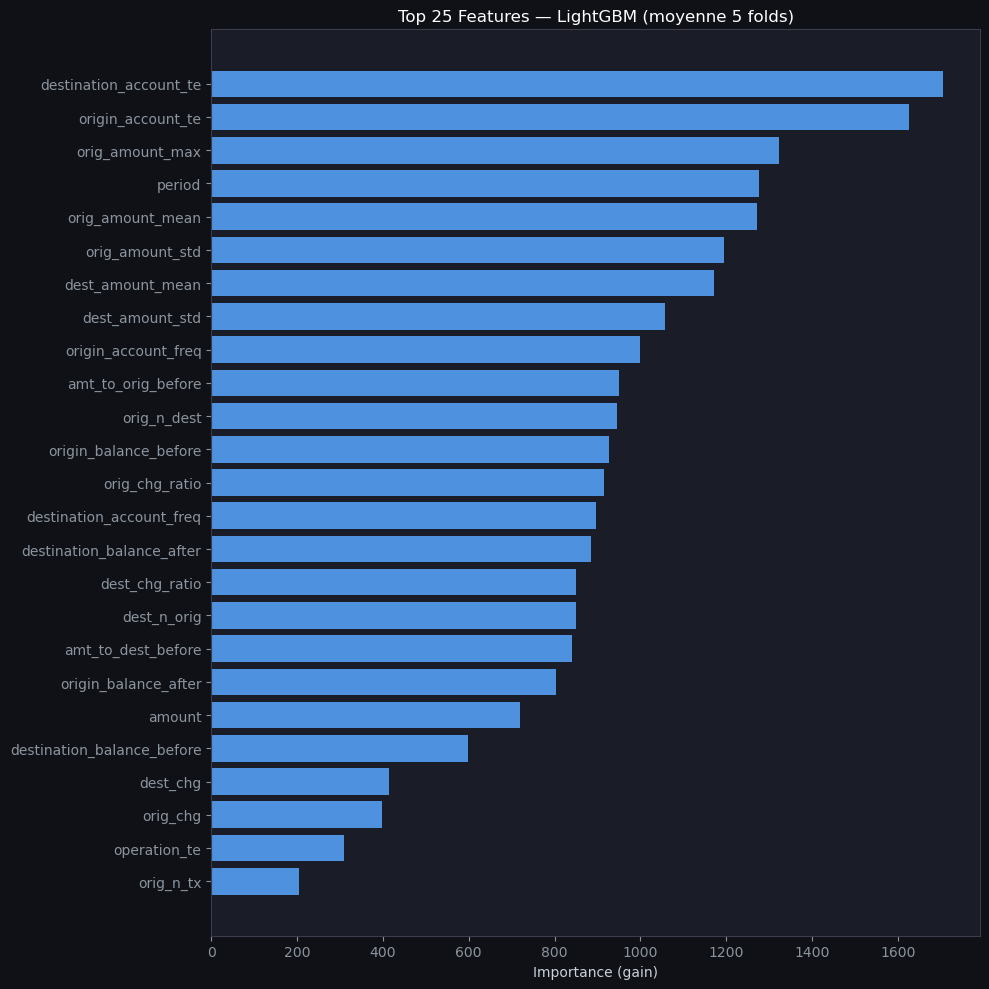


Top 10 features :
               feature  importance_mean
destination_account_te           1706.4
     origin_account_te           1626.0
       orig_amount_max           1322.8
                period           1277.0
      orig_amount_mean           1271.2
       orig_amount_std           1194.4
      dest_amount_mean           1172.6
       dest_amount_std           1057.4
   origin_account_freq            999.0
    amt_to_orig_before            950.4


In [7]:
import matplotlib.pyplot as plt

fi = feature_importances.copy()
fi["importance_mean"] = fi[[f"fold_{i}" for i in range(1, N_FOLDS+1)]].mean(axis=1)
fi = fi.sort_values("importance_mean", ascending=False)

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3d4d",   "axes.labelcolor": "#c9d1d9",
    "xtick.color": "#8b949e",      "ytick.color": "#8b949e",
    "text.color": "#c9d1d9",       "grid.color": "#2d3142",
    "grid.linestyle": "--",        "grid.alpha": 0.5,
})

fig, ax = plt.subplots(figsize=(10, 10), facecolor="#0f1117")
ax.barh(fi["feature"][:25][::-1], fi["importance_mean"][:25][::-1],
        color="#58a6ff", edgecolor="none", alpha=0.85)
ax.set_title("Top 25 Features — LightGBM (moyenne 5 folds)", color="white", fontsize=12)
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.savefig("eda_plots/07_feature_importance.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("\nTop 10 features :")
print(fi[["feature", "importance_mean"]].head(10).to_string(index=False))


## Analyse des prédictions OOF

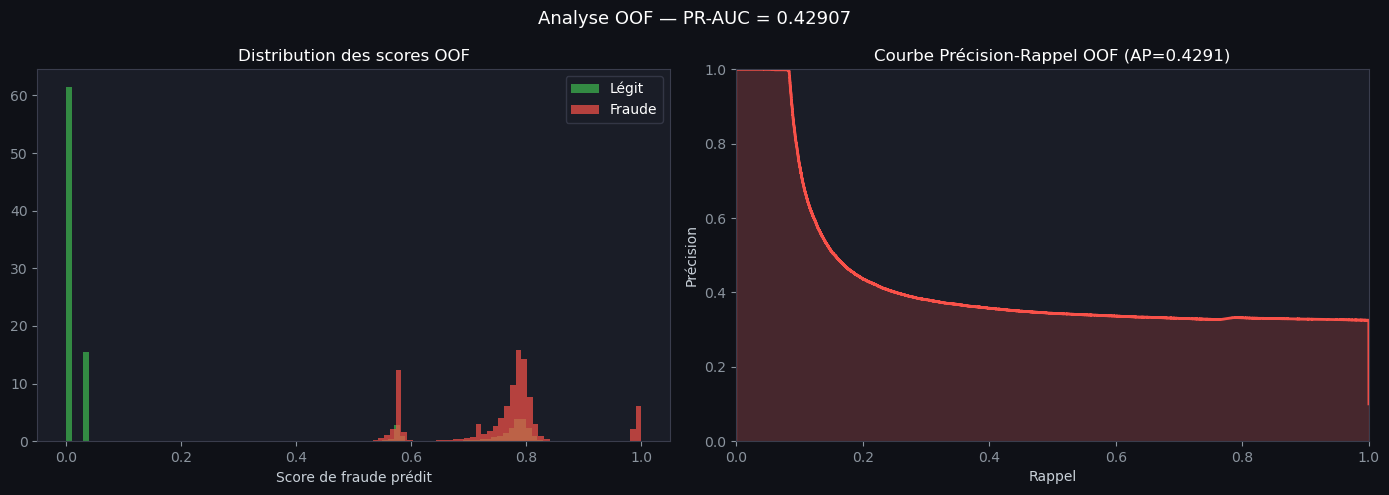

In [8]:
from sklearn.metrics import precision_recall_curve

# Distribution des scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f1117")
fig.suptitle(f"Analyse OOF — PR-AUC = {oof_ap:.5f}", fontsize=13, color="white")

ax = axes[0]
ax.hist(oof_preds[y == 0], bins=100, color="#3fb950", alpha=0.7, density=True, label="Légit")
ax.hist(oof_preds[y == 1], bins=100, color="#f85149", alpha=0.7, density=True, label="Fraude")
ax.set_title("Distribution des scores OOF", color="white")
ax.set_xlabel("Score de fraude prédit")
ax.legend(facecolor="#1a1d27", edgecolor="#3a3d4d", labelcolor="white")

ax = axes[1]
prec, rec, _ = precision_recall_curve(y, oof_preds)
ax.plot(rec, prec, color="#f85149", linewidth=2)
ax.fill_between(rec, prec, alpha=0.2, color="#f85149")
ax.set_title(f"Courbe Précision-Rappel OOF (AP={oof_ap:.4f})", color="white")
ax.set_xlabel("Rappel")
ax.set_ylabel("Précision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("eda_plots/08_oof_pr_curve.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


## Génération de la soumission

In [ ]:
test_preds_clipped = np.clip(test_preds, 0, 1)

submission = pd.DataFrame({
    "id":     test["id"],
    "target": test_preds_clipped,
})

submission.to_csv("dataset/submission_baseline.csv", index=False)

print("submission_baseline.csv généré")
print(f"Shape : {submission.shape}")
display(submission.head())

# Vérifications
assert submission.shape[0] == test.shape[0]
assert list(submission.columns) == ["id", "target"]
assert submission["id"].is_unique
assert submission["target"].between(0, 1).all()
assert set(submission["id"]) == set(sample_sub["id"])
print("Soumission valide !")
print(f"   Score OOF (PR-AUC) : {oof_ap:.5f}")
print(f"   target min={submission.target.min():.4f}  max={submission.target.max():.4f}  mean={submission.target.mean():.4f}")


submission_baseline.csv généré
Shape : (430100, 2)


,id,target
0,dtf_0000001_08a8a524,0.006932
1,dtf_0000002_ae0d3769,0.732461
2,dtf_0000003_843bab7c,0.729502
3,dtf_0000004_91643844,0.006933
4,dtf_0000005_17bd9a08,0.751199


Soumission valide !
   Score OOF (PR-AUC) : 0.42907
   target min=0.0069  max=0.9406  mean=0.2584
